    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
# from tqdm.notebook import tqdm
from IPython.display import clear_output
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [2]:
inds_30 = pd.read_csv('csv/30_industry.csv')
inds_30['Date'] = pd.to_datetime(inds_30['Date'])
inds_30 = inds_30.set_index('Date')
inds_30

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,-2.27,-1.16,1.67,-1.57,-2.49,-2.75,-2.40,-0.58,-1.76,-3.74,...,-1.26,2.47,2.24,-2.35,-0.97,-0.62,-2.57,-2.12,-4.11,-2.06
2000-01-04,-2.27,-1.11,0.64,-0.07,-2.72,-2.10,-3.62,-4.39,-1.74,-3.23,...,-4.40,-4.93,-5.68,-2.26,-2.58,-2.96,-3.46,-1.82,-3.90,-1.36
2000-01-05,0.10,1.33,-0.41,-0.40,-2.20,-1.42,1.96,2.32,3.39,1.37,...,0.01,-1.25,-0.90,2.16,0.27,2.16,-0.97,1.19,-0.47,0.21
2000-01-06,1.16,1.29,-1.28,-1.63,0.23,2.69,-0.45,2.68,4.31,-0.26,...,-1.92,-4.03,-5.41,3.17,3.00,3.39,-0.13,-0.73,3.23,0.26
2000-01-07,1.23,5.25,2.75,0.84,-1.23,5.40,1.08,7.61,1.59,1.67,...,0.93,3.46,3.56,1.70,1.10,2.85,4.79,1.50,2.01,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.46,0.21,0.37,0.16,0.28,0.72,1.71,0.58,0.46,0.83,...,0.64,0.19,0.18,0.29,0.30,0.27,0.52,0.63,0.53,0.23
2025-12-26,-0.08,-0.10,-0.21,0.68,-0.71,0.11,0.79,-0.05,0.36,0.37,...,-0.18,-0.15,0.33,0.47,-0.19,0.14,0.19,-0.24,-0.13,-0.56
2025-12-29,0.18,0.19,0.41,-0.44,-0.26,-0.16,0.00,-0.26,-0.37,-0.25,...,0.43,-0.35,-0.44,0.19,-0.30,-0.25,-0.16,-0.59,-0.71,0.44


In [3]:
# ── 고정 파라미터 ──
gamma = 0.0
x_min = 0.0
x_max = 1.0

N_STOCKS = len(inds_30.columns)

HORIZON    = 126    # 예측/MDD 제약 구간 (6개월)
REBAL      = 21     # 월별 리밸런싱
N          = HORIZON
M          = N_STOCKS
C          = 1.0
d          = 1.0
LAM_LIST   = [0.3, 0.5, 0.7]
DELTA_LIST = [20]
HIDDEN_DIM = 128
EPOCHS     = 150
BATCH_SIZE = 32
LR         = 1e-4
PATIENCE   = 30

# ── Fold 구조 ──
TRAIN_START       = "2000-01-01"   # Train 시작 (고정)
INITIAL_TRAIN_END = "2012-12-31"   # Fold 1 Train 종료
VAL_YEARS         = 5              # Val 기간
TEST_YEARS        = 1              # Test 기간 (1년씩 rolling)
TEST_START        = "2018-01-01"   # 전체 Test 시작
TEST_END          = "2025-12-31"   # 전체 Test 종료
N_FOLDS           = 8              # 2014~2025

# ── 실험 grid ──
LOOKBACK_LIST = [252, 504]
N1_LIST       = [0.1, 0.2, 0.3, 0.4]

configs = [
    {"LOOKBACK": lb, "n1": n1}
    for lb in LOOKBACK_LIST
    for n1 in N1_LIST
]

In [4]:
inds_30 = inds_30.sort_index()
inds_30 = inds_30[~inds_30.index.duplicated(keep='first')]
inds_30 = inds_30 / 100.0

stock_names = inds_30.columns.tolist()
full_np     = inds_30.values
full_dates  = inds_30.index

# =============================================================================
# 2. Fold 구조 생성 (Expanding Train / Rolling Val 1년 / Rolling Test 1년)
# =============================================================================
def date_to_idx(date_str):
    return full_dates.searchsorted(pd.Timestamp(date_str), side='left')

# Fold 생성: Val=year k, Test=year k+1
# Fold 1: Train[2000~2012] → Val[2013 ~ 2017] → Test[2014]
# Fold 12: Train[2000~2019] → Val[2020 ~ 2024] → Test[2025]
folds = []
for f in range(N_FOLDS):
    test_year = 2018 + f
    folds.append({
        "fold"           : f + 1,
        "train_end_idx"  : date_to_idx(f"{test_year - VAL_YEARS}-01-01"),
        "val_start_idx"  : date_to_idx(f"{test_year - VAL_YEARS}-01-01"),
        "val_end_idx"    : date_to_idx(f"{test_year}-01-01"),
        "test_start_idx" : date_to_idx(f"{test_year}-01-01"),
        "test_end_idx"   : min(date_to_idx(f"{test_year + TEST_YEARS}-01-01") + HORIZON,
                               len(full_np)),           # ← HORIZON 연장
        "val_year"       : f"{test_year - VAL_YEARS}~{test_year - 1}",
        "test_year"      : test_year,
    })

# =============================================================================
# 3. 표준화 (초기 Train 기간 2000~2012 고정)
# =============================================================================
init_train_end = date_to_idx("2013-01-01")
is_mean = full_np[:init_train_end].mean(axis=0)
is_std  = full_np[:init_train_end].std(axis=0)

# =============================================================================
# 4. 슬라이딩 윈도우 생성 함수
# =============================================================================
def make_windows(data, lookback, horizon, start, end):
    samples = []
    for t in range(max(start, lookback), end - horizon + 1):
        z_raw  = data[t - lookback : t]
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)
        r_real = data[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

# =============================================================================
# 5. Fold 구조 확인
# =============================================================================
print(f"전체  : {full_dates[0].date()} → {full_dates[-1].date()}  ({len(full_dates)} days)")
print(f"초기 Train : {TRAIN_START} → {full_dates[init_train_end-1].date()}")
print(f"총 Fold 수 : {len(folds)}\n")
print(f"{'Fold':>5}  {'Train End':>12}  {'Val':>6}  {'Test':>6}")
print("-" * 40)
for f in folds:
    print(f"  {f['fold']:3d}  "
          f"{str(full_dates[f['train_end_idx']-1].date()):>12}  "
          f"{f['val_year']:>6}  "
          f"{f['test_year']:>6}")

전체  : 2000-01-03 → 2025-12-31  (6539 days)
초기 Train : 2000-01-01 → 2012-12-31
총 Fold 수 : 8

 Fold     Train End     Val    Test
----------------------------------------
    1    2012-12-31  2013~2017    2018
    2    2013-12-31  2014~2018    2019
    3    2014-12-31  2015~2019    2020
    4    2015-12-31  2016~2020    2021
    5    2016-12-30  2017~2021    2022
    6    2017-12-29  2018~2022    2023
    7    2018-12-31  2019~2023    2024
    8    2019-12-31  2020~2024    2025


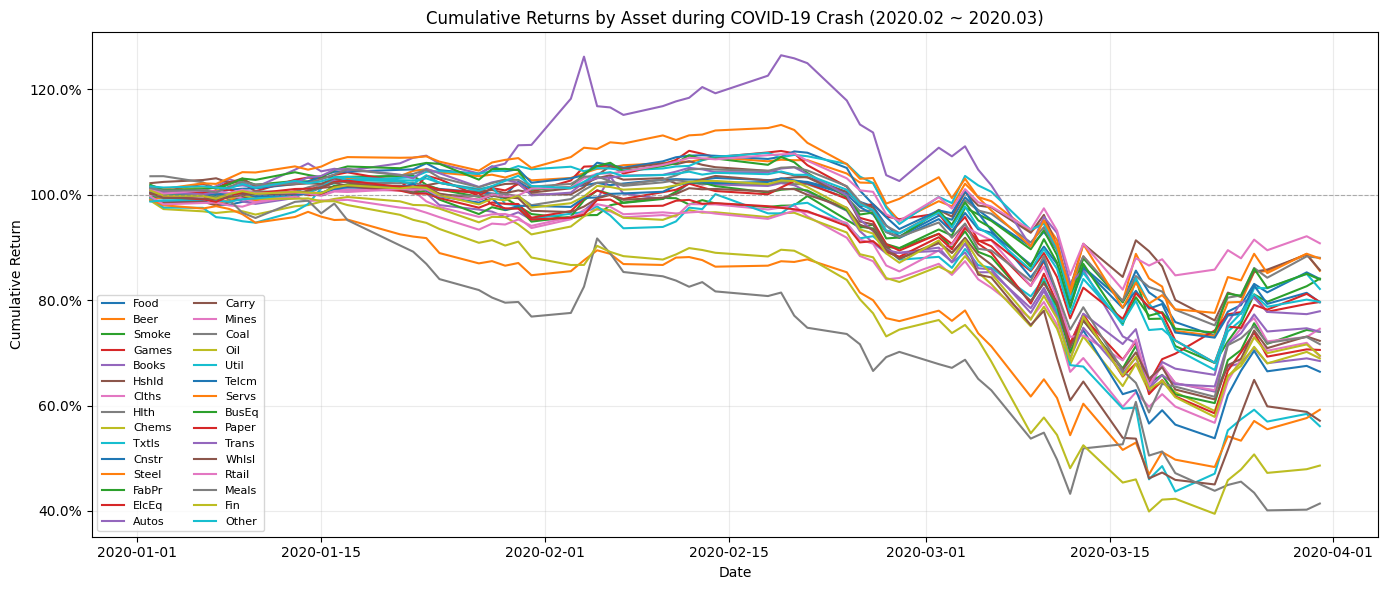

       Cumulative Return (%)
Coal                  -58.60
Oil                   -51.39
Txtls                 -43.92
Carry                 -42.89
Steel                 -40.81
Cnstr                 -33.59
Books                 -31.56
Chems                 -31.07
Clths                 -30.68
Fin                   -30.52
ElcEq                 -29.46
Meals                 -28.37
Whlsl                 -27.74
FabPr                 -26.01
Trans                 -26.01
Mines                 -25.45
Autos                 -22.12
Telcm                 -20.42
Games                 -20.37
Other                 -20.35
Paper                 -20.35
Util                  -17.89
BusEq                 -16.09
Food                  -16.00
Smoke                 -15.94
Beer                  -14.46
Hshld                 -14.30
Servs                 -12.12
Hlth                  -11.98
Rtail                  -9.23


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# ── 기간 설정 ──
START = "2020-01-01"
END   = "2020-03-31"

covid_df = inds_30[START:END]

# =============================================================================
# 1. 누적 수익률 시각화
# =============================================================================
cum_ret = (1 + covid_df).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
for col in cum_ret.columns:
    ax.plot(cum_ret.index, cum_ret[col], linewidth=1.5, label=col)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.set_title("Cumulative Returns by Asset during COVID-19 Crash (2020.02 ~ 2020.03)")
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date")
ax.legend(loc="lower left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# =============================================================================
# 2. 기간 총 누적 수익률 데이터프레임
# =============================================================================
total_ret = (1 + covid_df).prod() - 1

summary_df = pd.DataFrame({
    "Cumulative Return (%)": (total_ret * 100).round(2),
}).sort_values("Cumulative Return (%)")

print(summary_df.to_string())

In [6]:
import importlib, performance, dfl_mdd, pto_mdd, pto_mvo, plot_utils, plot_mdd, plot_allocation
importlib.reload(performance)
importlib.reload(dfl_mdd)
importlib.reload(pto_mdd)
importlib.reload(pto_mvo)
importlib.reload(plot_utils)
importlib.reload(plot_mdd)
importlib.reload(plot_allocation)

from performance import print_performance_table
from plot_utils import plot_multi_pnl, plot_overall_comparison
from plot_mdd import plot_mdd_distribution
from plot_allocation import plot_allocation
from dfl_mdd import (
    PredictionModel, build_optimization_layer, solve_portfolio,
    compute_cumulative_path, compute_realized_path, compute_return,
    compute_max_drawdown, dfl_loss, forward_pass,
    train_dfl_mdd, backtest_dfl_mdd, plot_pnl,
)
from pto_mdd import train_pto_mdd, backtest_pto_mdd
from pto_mvo import train_pto_mvo, backtest_pto_mvo

c:\Users\homeb\anaconda3\envs\LTK\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import os
import pickle

CKPT_DIR = "./checkpoint"
PLOT_DIR = "./plots"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

full_dates = inds_30.index
dfl_results_store = {}       # ← 추가

for delta_val in DELTA_LIST:
    for lam_val in LAM_LIST:
        print(f"\n{'='*50}")
        print(f"  delta={delta_val}, lam={lam_val}")
        print(f"{'='*50}")

        ckpt_path = os.path.join(CKPT_DIR,
                                 f"dfl_mdd_d{delta_val}_l{lam_val}.pkl")

        # ── 체크포인트 로드 ──
        if os.path.exists(ckpt_path):
            with open(ckpt_path, "rb") as f:
                ckpt = pickle.load(f)
            fold_results_map = ckpt["fold_results_map"]
            start_fold       = ckpt["completed_fold"] + 1
            print(f"  ✓ 체크포인트 로드: fold {ckpt['completed_fold']}까지 완료")
        else:
            fold_results_map = {(cfg["LOOKBACK"], cfg["n1"]): [] for cfg in configs}
            start_fold       = 1

        for fold_info in folds:
            fold_id = fold_info["fold"]

            if fold_id < start_fold:
                print(f"  ── Fold {fold_id} 스킵 (체크포인트)")
                continue

            print(f"\n  ── Fold {fold_id}  "
                  f"(val={fold_info['val_year']}, test={fold_info['test_year']}) ──")

            for cfg in configs:
                LOOKBACK = cfg["LOOKBACK"]
                n1       = cfg["n1"]

                print(f"\n  ▶ LB={LOOKBACK}, n1={n1} 학습 시작...")

                INPUT_DIM = LOOKBACK * N_STOCKS

                train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                             start=LOOKBACK,
                                             end=fold_info["train_end_idx"])
                val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                             start=fold_info["val_start_idx"],
                                             end=fold_info["val_end_idx"])
                val_samples   = val_samples[::HORIZON]
                rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                             start=fold_info["test_start_idx"],
                                             end=fold_info["test_end_idx"])
                rebal_samples = rebal_samples[::REBAL]

                train_dates = [
                    (str(full_dates[LOOKBACK + i])[:10],
                     str(full_dates[LOOKBACK + i + HORIZON - 1])[:10])
                    for i in range(len(train_samples))
                ]

                torch.manual_seed(42)

                pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
                opt_layer  = build_optimization_layer(N, M, gamma, delta=delta_val)

                pred_model, train_inaccurate = train_dfl_mdd(
                    pred_model, opt_layer, train_samples, val_samples,
                    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                    n1=n1, C=C, d=d, x_min=x_min, x_max=x_max, lam=lam_val,
                    is_mean=is_mean, is_std=is_std, delta=delta_val,
                    patience=PATIENCE, lr_patience=10, lr_factor=0.5,
                    train_dates=train_dates,
                )

                bt_dfl_mdd, bt_inaccurate = backtest_dfl_mdd(
                    pred_model=pred_model, opt_layer=opt_layer,
                    rebal_samples=rebal_samples, N=HORIZON, d=d, C=C,
                    n1=n1, x_min=x_min, x_max=x_max,
                    delta=delta_val, is_mean=is_mean, is_std=is_std,
                    stock_names=stock_names, rebal=REBAL,
                )

                fold_results_map[(LOOKBACK, n1)].extend(bt_dfl_mdd)

            # ── fold 완료 후 체크포인트 저장 ──
            with open(ckpt_path, "wb") as f:
                pickle.dump({
                    "fold_results_map" : fold_results_map,
                    "completed_fold"   : fold_id,
                    "delta_val"        : delta_val,
                    "lam_val"          : lam_val,
                }, f)
            print(f"\n  ✓ 체크포인트 저장 완료 (fold {fold_id})")

        # ── 전체 fold 결과 취합 ──
        all_results_dfl_mdd = [
            (fold_results_map[(cfg["LOOKBACK"], cfg["n1"])],
             f"DFL-MDD (LB={cfg['LOOKBACK']}, n1={cfg['n1']})")
            for cfg in configs
        ]
        dfl_results_store[(delta_val, lam_val)] = all_results_dfl_mdd

        # ── plot 저장 (plt.show 억제 후 저장 → 복원) ──
        plot_path = os.path.join(PLOT_DIR,
                                 f"dfl_mdd_{N_STOCKS}_inds_{lam_val}.png")
        _orig_show = plt.show
        plt.show = lambda: None                      # show 억제
        plot_multi_pnl(all_results_dfl_mdd,
                       title=f"DFL-MDD | delta={delta_val}, lam={lam_val}")
        plt.savefig(plot_path, bbox_inches="tight", dpi=150)
        plt.show = _orig_show                        # show 복원
        plt.show()
        print(f"\n  ✓ plot 저장: {plot_path}")

        mdd_plot_path = os.path.join(PLOT_DIR,
                                     f"mdd_dist_{N_STOCKS}_inds_{lam_val}.png")
        _orig_show = plt.show
        plt.show = lambda: None
        fig_mdd = plot_mdd_distribution(              # ← fig 받기
            all_results_dfl_mdd,
            title_prefix=f"DFL-MDD | delta={delta_val}, lam={lam_val}"
        )
        fig_mdd.savefig(mdd_plot_path, bbox_inches="tight", dpi=150)   # ← fig로 저장
        plt.show = _orig_show
        plt.show()
        print(f"\n  ✓ plot 저장: {mdd_plot_path}")

        print_performance_table(all_results_dfl_mdd,
                                title=f"DFL-MDD | delta={delta_val}, lam={lam_val}")


  delta=20, lam=0.3

  ── Fold 1  (val=2013~2017, test=2018) ──

  ▶ LB=252, n1=0.1 학습 시작...

── DFL-MDD Training (with Val Early Stopping + LR Scheduler) ──
  Epoch   1/150  train=0.085691  val=0.017299  lr=1.00e-04  *
  Epoch   5/150  train=0.057254  val=0.019625  lr=1.00e-04  (4/30)  [inaccurate=2]
  Epoch  10/150  train=0.052448  val=0.018575  lr=1.00e-04  (4/30)  [inaccurate=3]
  Epoch  15/150  train=0.050476  val=0.022165  lr=1.00e-04  (9/30)  [inaccurate=4]
  Epoch  20/150  train=0.049180  val=0.021223  lr=5.00e-05  (14/30)  [inaccurate=4]
  Epoch  25/150  train=0.048119  val=0.022493  lr=5.00e-05  (19/30)  [inaccurate=5]
  Epoch  30/150  train=0.047890  val=0.022624  lr=2.50e-05  (24/30)  [inaccurate=7]
  Epoch  35/150  train=0.047160  val=0.022222  lr=2.50e-05  (29/30)  [inaccurate=8]
  Early stopping at epoch 36  (best val=0.017239)

  ⚠ Inaccurate 발생: 총 8회
    epoch=  3, batch=  6, count=1  [2001-01-05 ~ 2012-08-21]
    epoch=  4, batch= 81, count=1  [2001-09-07 ~ 2012-12-1

Backtesting: 100%|██████████| 12/12 [00:00<00:00, 126.18it/s]

    1    0.0321    0.2117   2.0734%  n= 3  {'Hlth': np.float32(0.427), 'Beer': np.float32(0.345), 'Food': np.float32(0.228)}
    2   -0.0493   -0.3086   7.8951%  n= 3  {'Beer': np.float32(0.529), 'Hlth': np.float32(0.315), 'Util': np.float32(0.156)}
    3   -0.0139   -0.0777   5.8400%  n= 4  {'Beer': np.float32(0.574), 'Hlth': np.float32(0.226), 'Food': np.float32(0.147)}
    4   -0.0385   -0.2198   6.0313%  n= 4  {'Beer': np.float32(0.376), 'Hlth': np.float32(0.365), 'Food': np.float32(0.168)}
    5    0.0181    0.0965   1.6273%  n= 4  {'Beer': np.float32(0.543), 'Util': np.float32(0.331), 'Hlth': np.float32(0.082)}
    6    0.0393    0.2269   0.7580%  n= 4  {'Beer': np.float32(0.429), 'Util': np.float32(0.232), 'Food': np.float32(0.17)}
    7    0.0352    0.1742   1.2793%  n= 4  {'Beer': np.float32(0.593), 'Hlth': np.float32(0.286), 'Food': np.float32(0.068)}
    8    0.0099    0.0525   1.8158%  n= 4  {'Beer': np.float32(0.516), 'Hlth': np.float32(0.22), 'Util': np.float32(0.143)}
  


── DFL-MDD Training (with Val Early Stopping + LR Scheduler) ──
  Epoch   1/150  train=0.087771  val=0.039308  lr=1.00e-04  *
  Epoch   5/150  train=0.061532  val=0.035114  lr=1.00e-04  (2/30)
  Epoch  10/150  train=0.054929  val=0.036294  lr=1.00e-04  (2/30)
  Epoch  15/150  train=0.053049  val=0.033575  lr=1.00e-04  (2/30)
  Epoch  20/150  train=0.051606  val=0.031270  lr=1.00e-04  *
  Epoch  25/150  train=0.052795  val=0.032559  lr=1.00e-04  (4/30)
  Epoch  30/150  train=0.050553  val=0.032633  lr=1.00e-04  (9/30)
  Epoch  35/150  train=0.050751  val=0.031840  lr=5.00e-05  (14/30)
  Epoch  40/150  train=0.052117  val=0.034826  lr=5.00e-05  (3/30)
  Epoch  45/150  train=0.051697  val=0.030611  lr=5.00e-05  (8/30)
  Epoch  50/150  train=0.050692  val=0.033410  lr=2.50e-05  (13/30)
  Epoch  55/150  train=0.051491  val=0.029349  lr=2.50e-05  (18/30)
  Epoch  60/150  train=0.050173  val=0.030331  lr=1.25e-05  (23/30)
  Epoch  65/150  train=0.049400  val=0.029543  lr=1.25e-05  (28/30)
  

Backtesting: 100%|██████████| 12/12 [00:00<00:00, 130.93it/s]

...

Backtesting:   0%|          | 0/12 [00:00<?, ?it/s]

    1    0.0028    0.0080   3.8111%  n= 2  {'Food': np.float32(0.868), 'Beer': np.float32(0.132), 'Whlsl': np.float32(0.0)}
    2    0.0304    0.0852   2.3076%  n= 2  {'Food': np.float32(0.899), 'Oil': np.float32(0.101), 'Rtail': np.float32(0.0)}
    3    0.0186    0.0556   6.0650%  n= 3  {'Food': np.float32(0.877), 'Games': np.float32(0.107), 'Servs': np.float32(0.015)}
    4    0.0016    0.0056   4.3472%  n= 2  {'Food': np.float32(0.942), 'Beer': np.float32(0.058), 'Games': np.float32(-0.0)}
    5   -0.0053   -0.0187   7.1394%  n= 1  {'Food': np.float32(1.0), 'Whlsl': np.float32(0.0), 'Games': np.float32(0.0)}
    6   -0.0075   -0.0265   6.7776%  n= 2  {'Food': np.float32(0.967), 'Whlsl': np.float32(0.033), 'Beer': np.float32(0.0)}
    7    0.0372    0.1333   1.9980%  n= 2  {'Food': np.float32(0.965), 'Rtail': np.float32(0.035), 'Meals': np.float32(0.0)}
    8   -0.0181   -0.0639   3.8672%  n= 1  {'Food': np.float32(1.0), 'Beer': np.float32(0.0), 'Whlsl': np.float32(0.0)}
    9   -0.

Backtesting: 100%|██████████| 12/12 [00:00<00:00, 109.40it/s]



  ✓ Backtest Inaccurate 없음

  ✓ 체크포인트 저장 완료 (fold 5)

  ── Fold 6  (val=2018~2022, test=2023) ──

  ▶ LB=252, n1=0.1 학습 시작...

── DFL-MDD Training (with Val Early Stopping + LR Scheduler) ──
  Epoch   1/150  train=0.066386  val=0.088083  lr=1.00e-04  *  [inaccurate=1]
  Epoch   5/150  train=0.058558  val=0.075973  lr=1.00e-04  *  [inaccurate=2]
  Epoch  10/150  train=0.052194  val=0.072970  lr=1.00e-04  *  [inaccurate=4]
  Epoch  15/150  train=0.045630  val=0.063586  lr=1.00e-04  (1/30)  [inaccurate=5]
  Epoch  20/150  train=0.043811  val=0.081359  lr=1.00e-04  (2/30)  [inaccurate=6]


KeyboardInterrupt: 

In [ ]:
for delta_val in DELTA_LIST:
    print(f"\n{'='*50}")
    print(f"  delta={delta_val}")
    print(f"{'='*50}")

    fold_results_map = {(cfg["LOOKBACK"], cfg["n1"]): [] for cfg in configs}

    for fold_info in folds:
        fold_id = fold_info["fold"]
        print(f"\n  ── Fold {fold_id}  "
              f"(val={fold_info['val_year']}, test={fold_info['test_year']}) ──")

        for cfg in configs:
            LOOKBACK = cfg["LOOKBACK"]
            n1       = cfg["n1"]

            print(f"\n  ▶ LB={LOOKBACK}, n1={n1} 학습 시작...")

            INPUT_DIM = LOOKBACK * N_STOCKS

            train_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=LOOKBACK,
                                         end=fold_info["train_end_idx"])
            val_samples   = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=fold_info["val_start_idx"],
                                         end=fold_info["val_end_idx"])
            val_samples   = val_samples[::HORIZON]

            rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                                         start=fold_info["test_start_idx"],
                                         end=fold_info["test_end_idx"])
            rebal_samples = rebal_samples[::REBAL]

            torch.manual_seed(42)

            model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
            train_pto_mdd(model_pto_mdd, train_samples, val_samples,
                          EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

            bt_pto_mdd = backtest_pto_mdd(
                model_pto_mdd, rebal_samples, N, d, C,
                n1=n1, x_min=x_min, x_max=x_max, gamma=gamma,
                delta=delta_val,
                is_mean=is_mean, is_std=is_std,
                stock_names=stock_names, rebal=REBAL,
            )

            fold_results_map[(LOOKBACK, n1)].extend(bt_pto_mdd)

    # ── 전체 fold 결과 취합 ──
    all_results_pto_mdd = [
        (fold_results_map[(cfg["LOOKBACK"], cfg["n1"])],
         f"PTO-MDD (LB={cfg['LOOKBACK']}, n1={cfg['n1']})")
        for cfg in configs
    ]

    # ── plot_multi_pnl 저장 ──
    plot_path = os.path.join(PLOT_DIR,
                             f"pto_mdd_{N_STOCKS}_inds_{delta_val}.png")
    _orig_show = plt.show
    plt.show = lambda: None
    plot_multi_pnl(all_results_pto_mdd, title=f"PTO-MDD | delta={delta_val}")
    plt.savefig(plot_path, bbox_inches="tight", dpi=150)
    plt.show = _orig_show
    plt.show()
    print(f"\n  ✓ plot 저장: {plot_path}")

    # ── plot_mdd_distribution 저장 ──
    mdd_plot_path = os.path.join(PLOT_DIR,
                                 f"mdd_dist_pto_mdd_{N_STOCKS}_inds_{delta_val}.png")
    _orig_show = plt.show
    plt.show = lambda: None
    fig_mdd = plot_mdd_distribution(
        all_results_pto_mdd,
        title_prefix=f"PTO-MDD | delta={delta_val}"
    )
    fig_mdd.savefig(mdd_plot_path, bbox_inches="tight", dpi=150)
    plt.show = _orig_show
    plt.show()
    print(f"\n  ✓ plot 저장: {mdd_plot_path}")

    print_performance_table(all_results_pto_mdd,
                            title=f"PTO-MDD | delta={delta_val}")


  delta=20

  ── Fold 1  (val=2013~2017, test=2018) ──

  ▶ LB=252, n1=0.1 학습 시작...

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/150  train=0.005574  val=0.002396  *
  Epoch   5/150  train=0.000880  val=0.000658  *
  Epoch  10/150  train=0.000320  val=0.000179  *
  Epoch  15/150  train=0.000307  val=0.000152  *
  Epoch  20/150  train=0.000305  val=0.000144  *
  Epoch  25/150  train=0.000302  val=0.000141  *
  Epoch  30/150  train=0.000302  val=0.000141  (2/30)
  Epoch  35/150  train=0.000302  val=0.000141  (1/30)
  Epoch  40/150  train=0.000302  val=0.000141  (6/30)
  Epoch  45/150  train=0.000302  val=0.000141  (11/30)
  Epoch  50/150  train=0.000302  val=0.000141  *
  Epoch  55/150  train=0.000302  val=0.000141  (5/30)
  Epoch  60/150  train=0.000302  val=0.000141  (3/30)
  Epoch  65/150  train=0.000302  val=0.000141  (8/30)
  Epoch  70/150  train=0.000303  val=0.000141  (13/30)
  Epoch  75/150  train=0.000303  val=0.000141  (18/30)
  Epoch  80/150  train=0.000302 

KeyboardInterrupt: 

In [ ]:
for delta_val in DELTA_LIST:
    print(f"\n{'='*50}")
    print(f"  delta={delta_val}")
    print(f"{'='*50}")

    fold_results_map = {lookback: [] for lookback in LOOKBACK_LIST}

    for fold_info in folds:
        fold_id = fold_info["fold"]
        print(f"\n  ── Fold {fold_id}  "
              f"(val={fold_info['val_year']}, test={fold_info['test_year']}) ──")

        for lookback in LOOKBACK_LIST:
            print(f"\n  ▶ LB={lookback} 학습 시작...")

            INPUT_DIM = lookback * N_STOCKS

            train_samples = make_windows(full_np, lookback, HORIZON,
                                         start=lookback,
                                         end=fold_info["train_end_idx"])
            val_samples   = make_windows(full_np, lookback, HORIZON,
                                         start=fold_info["val_start_idx"],
                                         end=fold_info["val_end_idx"])
            val_samples   = val_samples[::HORIZON]

            rebal_samples = make_windows(full_np, lookback, HORIZON,
                                         start=fold_info["test_start_idx"],
                                         end=fold_info["test_end_idx"])
            rebal_samples = rebal_samples[::REBAL]

            torch.manual_seed(42)

            model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
            train_pto_mvo(model_pto_mvo, train_samples, val_samples,
                          EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

            bt_pto_mvo = backtest_pto_mvo(
                model_pto_mvo, rebal_samples, N, d, C,
                delta=delta_val,
                x_min=x_min, x_max=x_max, gamma=gamma,
                is_mean=is_mean, is_std=is_std,
                stock_names=stock_names,
                rebal=REBAL,
            )

            fold_results_map[lookback].extend(bt_pto_mvo)

    # ── 전체 fold 결과 취합 ──
    all_results_mvo = [
        (fold_results_map[lookback], f"PTO-MVO (LB={lookback})")
        for lookback in LOOKBACK_LIST
    ]

    # ── plot_multi_pnl 저장 ──
    plot_path = os.path.join(PLOT_DIR,
                             f"pto_mvo_{N_STOCKS}_inds_{delta_val}.png")
    _orig_show = plt.show
    plt.show = lambda: None
    plot_multi_pnl(all_results_mvo, title=f"PTO-MVO | delta={delta_val}")
    plt.savefig(plot_path, bbox_inches="tight", dpi=150)
    plt.show = _orig_show
    plt.show()
    print(f"\n  ✓ plot 저장: {plot_path}")

    # ── plot_mdd_distribution 저장 ──
    mdd_plot_path = os.path.join(PLOT_DIR,
                                 f"mdd_dist_pto_mvo_{N_STOCKS}_inds_{delta_val}.png")
    _orig_show = plt.show
    plt.show = lambda: None
    fig_mdd = plot_mdd_distribution(
        all_results_mvo,
        title_prefix=f"PTO-MVO | delta={delta_val}"
    )
    fig_mdd.savefig(mdd_plot_path, bbox_inches="tight", dpi=150)
    plt.show = _orig_show
    plt.show()
    print(f"\n  ✓ plot 저장: {mdd_plot_path}")

    print_performance_table(all_results_mvo,
                            title=f"PTO-MVO | delta={delta_val}")

In [ ]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
from performance import build_equity_curve, compute_performance

CKPT_DIR = "./checkpoint"
PLOT_DIR  = "./plot"

# ── 체크포인트에서 dfl_results_store 복원 ──
dfl_results_store = {}
for delta_val in DELTA_LIST:
    for lam_val in LAM_LIST:
        ckpt_path = os.path.join(CKPT_DIR, f"dfl_mdd_d{delta_val}_l{lam_val}.pkl")
        if os.path.exists(ckpt_path):
            with open(ckpt_path, "rb") as f:
                ckpt = pickle.load(f)
            fold_results_map = ckpt["fold_results_map"]
            dfl_results_store[(delta_val, lam_val)] = [
                (fold_results_map[(cfg["LOOKBACK"], cfg["n1"])],
                 f"DFL-MDD (LB={cfg['LOOKBACK']}, n1={cfg['n1']})")
                for cfg in configs
            ]
            print(f"  ✓ 로드: delta={delta_val}, lam={lam_val}  "
                  f"(fold {ckpt['completed_fold']}까지)")
        else:
            print(f"  ✗ 체크포인트 없음: {ckpt_path}")

plot_overall_comparison(
    dfl_results_store, all_results_pto_mdd, all_results_mvo,
    DELTA_LIST, LAM_LIST, LOOKBACK_LIST,
    N_STOCKS, PLOT_DIR
)

In [ ]:
plot_allocation(
    dfl_results_store, all_results_mvo,
    DELTA_LIST, LAM_LIST, LOOKBACK_LIST,
    stock_names, folds, full_dates,
    REBAL, HORIZON, N_STOCKS, PLOT_DIR
)
